# <b> Comparing retrievals for the measured & TROPOMI-derived OCI Spectra <b>

## <b> Bulk comparison <b>

In [90]:
import numpy as np
import pandas as pd
import os
import xarray as xr
import matplotlib.pyplot as plt


In [91]:
# matchup products + SIF retrievals (χ²-fixed run)
run_dir = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/TROPOMI_OCI_colocation_data/runs/july2025_d01-31"
matchup_nc = os.path.join(run_dir, "products", "matchup.nc")

# χ²-corrected matchup retrievals live under sif_retrieval/chi2_correct_retrieval/
root_dir = os.path.join(run_dir, "sif_retrieval", "chi2_correct_retrieval")
test_name = "sif_retrieval_nPC_15_npoly_5/"

path_sim = os.path.join(root_dir, test_name, "matchup_sif_sim_noisy.nc")
ds_sim = xr.open_dataset(path_sim)

path_meas = os.path.join(root_dir, test_name, "matchup_sif_meas.nc")
ds_meas = xr.open_dataset(path_meas)


In [92]:
# statistics on # of converged retrievals
sim_converged = ds_sim["converged"].values
meas_converged = ds_meas["converged"].values
print("Number of converged retrievals:")
print(f"Real OCI spectra: {np.sum(meas_converged)}")
print(f"Simulated spectra: {np.sum(sim_converged)}")


Number of converged retrievals:
Real OCI spectra: 7021
Simulated spectra: 5709


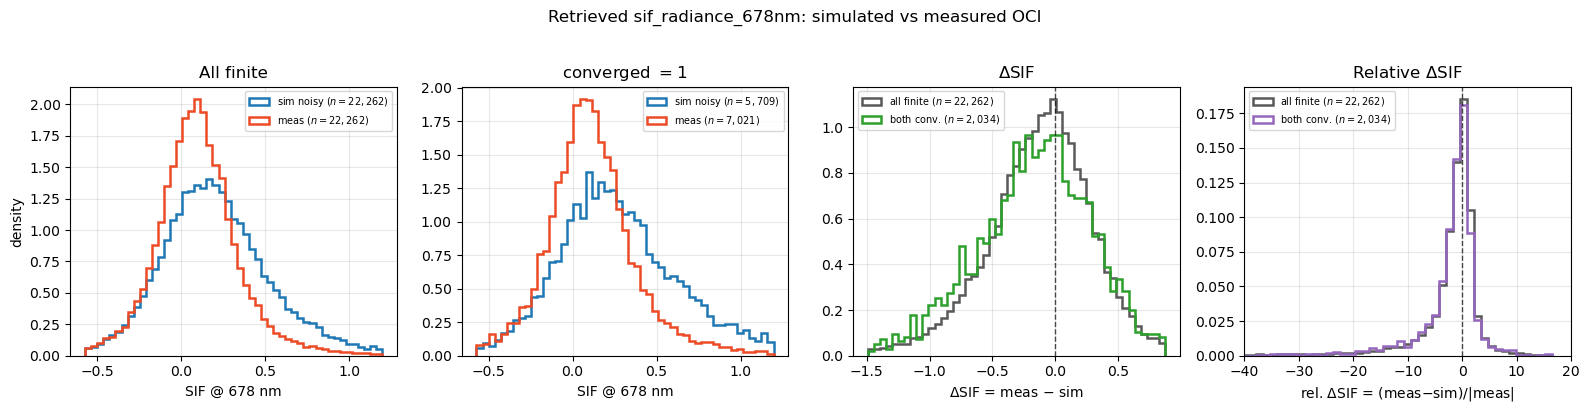

all finite   median sim=0.1846  meas=0.08534
converged    median sim=0.2413  meas=0.09296
ΔSIF median  all=-0.09857  both-conv=-0.1438
rel ΔSIF median all=-0.6968  both-conv=-0.8377


In [93]:
# SIF distributions: all finite | converged | ΔSIF | relative ΔSIF
sif_sim = np.asarray(ds_sim["sif_radiance_678nm"].values, dtype=float)
sif_meas = np.asarray(ds_meas["sif_radiance_678nm"].values, dtype=float)
conv_sim = np.asarray(ds_sim["converged"].values).astype(bool)
conv_meas = np.asarray(ds_meas["converged"].values).astype(bool)

sim_all = sif_sim[np.isfinite(sif_sim)]
meas_all = sif_meas[np.isfinite(sif_meas)]
sim_ok = sif_sim[conv_sim & np.isfinite(sif_sim)]
meas_ok = sif_meas[conv_meas & np.isfinite(sif_meas)]

# paired differences (same match index)
m_all = np.isfinite(sif_sim) & np.isfinite(sif_meas)
m_ok = m_all & conv_sim & conv_meas
diff_all = sif_meas[m_all] - sif_sim[m_all]
diff_ok = sif_meas[m_ok] - sif_sim[m_ok]

# relative ΔSIF = (meas − sim) / |meas|
eps = 1e-6
rel_all = diff_all / np.maximum(np.abs(sif_meas[m_all]), eps)
rel_ok = diff_ok / np.maximum(np.abs(sif_meas[m_ok]), eps)

pool = np.concatenate([a for a in (sim_all, meas_all) if a.size])
lo, hi = np.nanpercentile(pool, [1, 99])
bins = np.linspace(lo, hi, 50)

diff_pool = np.concatenate([a for a in (diff_all, diff_ok) if a.size])
dlo, dhi = np.nanpercentile(diff_pool, [1, 99])
dbins = np.linspace(dlo, dhi, 50)

rel_pool = np.concatenate([a for a in (rel_all, rel_ok) if a.size])
rlo, rhi = np.nanpercentile(rel_pool, [1, 99])
rbins = np.linspace(rlo, rhi, 80)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))

for ax, sim_v, meas_v, title in [
    (axes[0], sim_all, meas_all, "All finite"),
    (axes[1], sim_ok, meas_ok, r"converged $= 1$"),
]:
    ax.hist(sim_v, bins=bins, histtype="step", lw=1.8, density=True,
            color="#1f77b4", label=fr"sim noisy ($n={sim_v.size:,}$)")
    ax.hist(meas_v, bins=bins, histtype="step", lw=1.8, density=True,
            color="#EC4B26", label=fr"meas ($n={meas_v.size:,}$)")
    ax.set_xlabel(r"SIF @ 678 nm")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel("density")

ax = axes[2]
ax.hist(diff_all, bins=dbins, histtype="step", lw=1.8, density=True,
        color="0.35", label=fr"all finite ($n={diff_all.size:,}$)")
ax.hist(diff_ok, bins=dbins, histtype="step", lw=1.8, density=True,
        color="#2ca02c", label=fr"both conv. ($n={diff_ok.size:,}$)")
ax.axvline(0.0, color="k", ls="--", lw=1.0, alpha=0.7)
ax.set_xlabel(r"$\Delta$SIF = meas − sim")
ax.set_title(r"$\Delta$SIF")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

ax = axes[3]
ax.hist(rel_all, bins=rbins, histtype="step", lw=1.8, density=True,
        color="0.35", label=fr"all finite ($n={rel_all.size:,}$)")
ax.hist(rel_ok, bins=rbins, histtype="step", lw=1.8, density=True,
        color="#9467bd", label=fr"both conv. ($n={rel_ok.size:,}$)")
ax.axvline(0.0, color="k", ls="--", lw=1.0, alpha=0.7)
ax.set_xlabel(r"rel. $\Delta$SIF = (meas−sim)$/|$meas$|$")
ax.set_xlim(-40, 20)
ax.set_title(r"Relative $\Delta$SIF")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

fig.suptitle("Retrieved sif_radiance_678nm: simulated vs measured OCI", y=1.02)
plt.tight_layout()
plt.show()

print(f"all finite   median sim={np.nanmedian(sim_all):.4g}  meas={np.nanmedian(meas_all):.4g}")
print(f"converged    median sim={np.nanmedian(sim_ok):.4g}  meas={np.nanmedian(meas_ok):.4g}")
print(f"ΔSIF median  all={np.nanmedian(diff_all):.4g}  both-conv={np.nanmedian(diff_ok):.4g}")
print(f"rel ΔSIF median all={np.nanmedian(rel_all):.4g}  both-conv={np.nanmedian(rel_ok):.4g}")


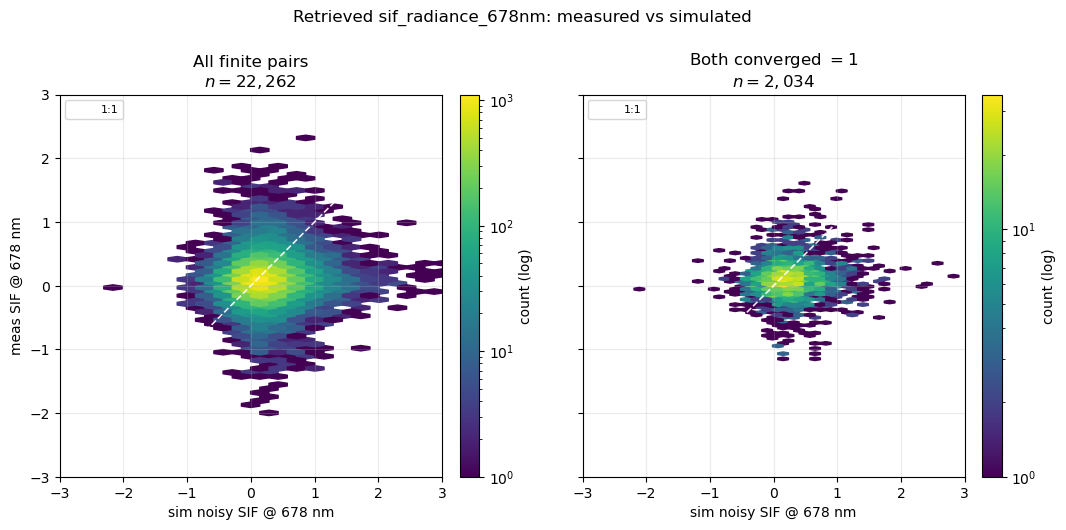

converged pairs: n=2,034  corr=0.045  mean(meas−sim)=-0.179


In [94]:
# Scatter-density: measured vs simulated sif_radiance_678nm (same match index)
x_all, y_all = sif_sim, sif_meas
m_all = np.isfinite(x_all) & np.isfinite(y_all)
m_ok = m_all & conv_sim & conv_meas

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, mask, title in [
    (axes[0], m_all, "All finite pairs"),
    (axes[1], m_ok, r"Both converged $= 1$"),
]:
    x, y = x_all[mask], y_all[mask]
    hb = ax.hexbin(x, y, gridsize=60, mincnt=1, bins="log", cmap="viridis")
    # 1:1 reference over data range
    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    ax.plot([lo, hi], [lo, hi], "w--", lw=1.2, alpha=0.9, label="1:1")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"sim noisy SIF @ 678 nm")
    ax.set_title(f"{title}\n$n={x.size:,}$")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)
    cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("count (log)")

axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_ylabel(r"meas SIF @ 678 nm")
fig.suptitle("Retrieved sif_radiance_678nm: measured vs simulated", y=1.02)
plt.tight_layout()
plt.show()

# quick stats on converged pairs
if m_ok.any():
    r = np.corrcoef(x_all[m_ok], y_all[m_ok])[0, 1]
    bias = np.nanmean(y_all[m_ok] - x_all[m_ok])
    print(f"converged pairs: n={m_ok.sum():,}  corr={r:.3f}  mean(meas−sim)={bias:.4g}")


both converged with finite spectra/|ΔVZA|/SIF: 2,034 / 22,262
bin 1/4: |ΔVZA| ∈ [0.05, 7.65]°  n=509  show=4
bin 2/4: |ΔVZA| ∈ [7.65, 16.36]°  n=508  show=4
bin 3/4: |ΔVZA| ∈ [16.36, 26.48]°  n=508  show=4
bin 4/4: |ΔVZA| ∈ [26.48, 65.89]°  n=509  show=4


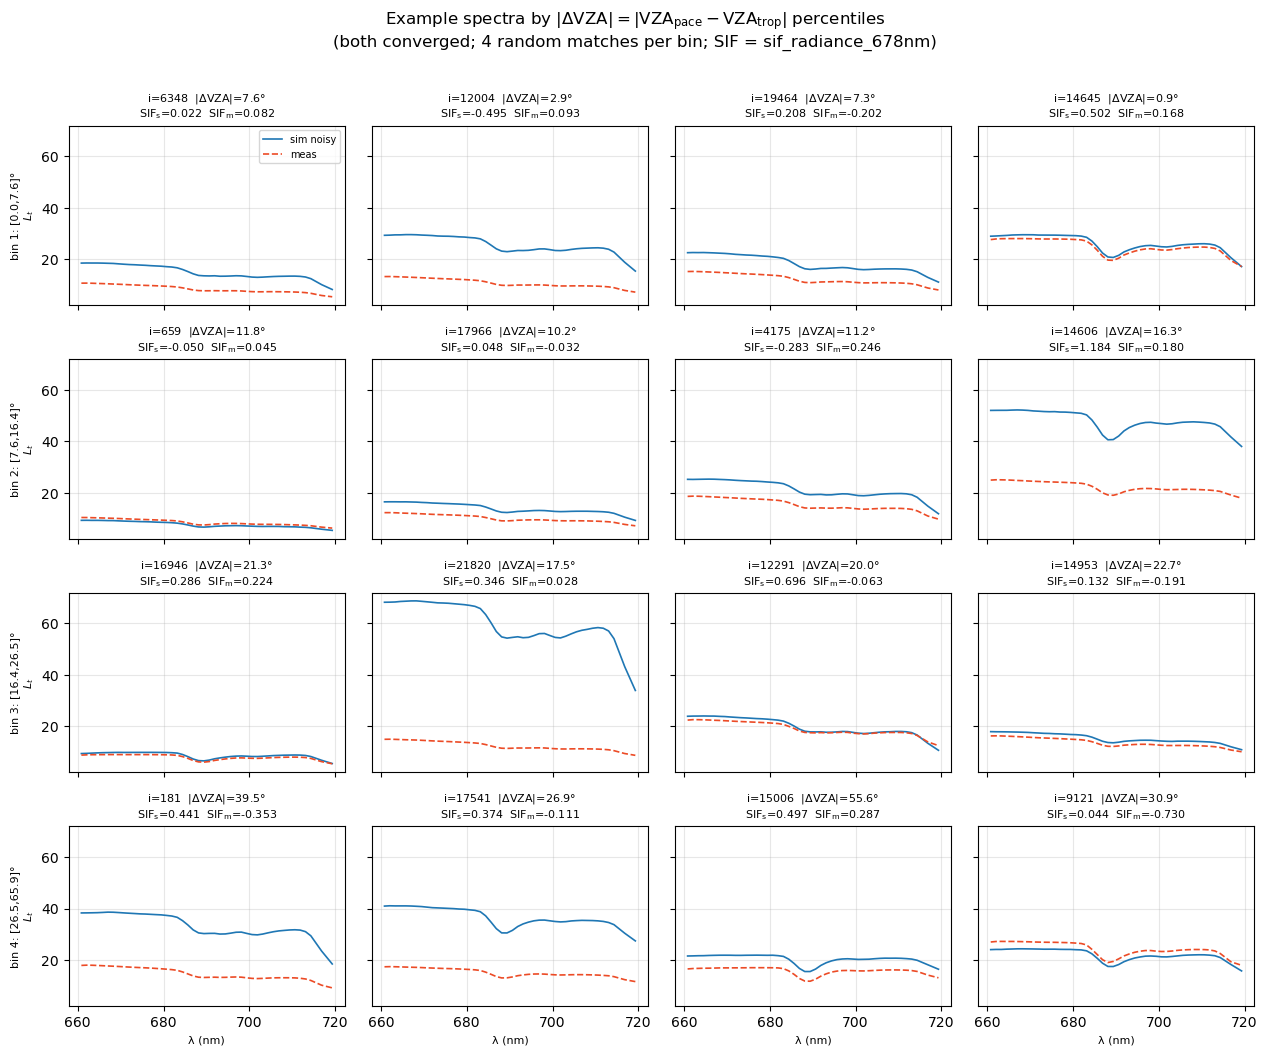

In [95]:
# Example spectra: 4 abs(ΔVZA) percentile bins × 4 random both-converged matches
# |ΔVZA| = |vza_pace − vza_trop|; spectra from matchup.nc; SIF from retrieval NCs

RNG = np.random.default_rng(0)
N_BINS, N_PER_BIN = 4, 4

path_mu = matchup_nc  # from cell above: run_dir/products/matchup.nc
ds_mu = xr.open_dataset(path_mu)
band = np.asarray(ds_mu["band"].values, dtype=float)
lt_sim = np.asarray(ds_mu["lt_oci_sim_noisy"].values, dtype=float)   # (match, band)
lt_meas = np.asarray(ds_mu["lt_oci_meas"].values, dtype=float)
vza_p = np.asarray(ds_sim["vza_pace"].values, dtype=float)
vza_t = np.asarray(ds_sim["vza_trop"].values, dtype=float)
abs_dvza = np.abs(vza_p - vza_t)

both = (
    conv_sim & conv_meas
    & np.isfinite(abs_dvza)
    & np.isfinite(lt_sim).all(axis=1)
    & np.isfinite(lt_meas).all(axis=1)
    & np.isfinite(sif_sim)
    & np.isfinite(sif_meas)
)
idx = np.flatnonzero(both)
print(f"both converged with finite spectra/|ΔVZA|/SIF: {idx.size:,} / {abs_dvza.size:,}")

qs = np.linspace(0, 100, N_BINS + 1)
edges = np.percentile(abs_dvza[idx], qs)

fig, axes = plt.subplots(
    N_BINS, N_PER_BIN, figsize=(3.2 * N_PER_BIN, 2.6 * N_BINS), sharex=True, sharey=True
)

for b in range(N_BINS):
    lo_e, hi_e = edges[b], edges[b + 1]
    if b < N_BINS - 1:
        in_bin = idx[(abs_dvza[idx] >= lo_e) & (abs_dvza[idx] < hi_e)]
    else:
        in_bin = idx[(abs_dvza[idx] >= lo_e) & (abs_dvza[idx] <= hi_e)]
    n_pick = min(N_PER_BIN, in_bin.size)
    pick = RNG.choice(in_bin, size=n_pick, replace=False) if n_pick else np.array([], dtype=int)
    print(
        f"bin {b+1}/{N_BINS}: |ΔVZA| ∈ [{lo_e:.2f}, {hi_e:.2f}]°  "
        f"n={in_bin.size:,}  show={n_pick}"
    )

    for j in range(N_PER_BIN):
        ax = axes[b, j]
        if j >= n_pick:
            ax.set_visible(False)
            continue
        i = int(pick[j])
        ax.plot(band, lt_sim[i], color="#1f77b4", lw=1.2, label="sim noisy")
        ax.plot(band, lt_meas[i], color="#EC4B26", lw=1.2, ls="--", label="meas")
        ax.set_title(
            fr"i={i}  $|\Delta$VZA$|$={abs_dvza[i]:.1f}°"
            f"\nSIF$_\\mathrm{{s}}$={sif_sim[i]:.3f}  SIF$_\\mathrm{{m}}$={sif_meas[i]:.3f}",
            fontsize=8,
        )
        ax.grid(True, alpha=0.3)
        if b == N_BINS - 1:
            ax.set_xlabel("λ (nm)", fontsize=8)
        if j == 0:
            ax.set_ylabel(
                fr"bin {b+1}: [{lo_e:.1f},{hi_e:.1f}]°" + "\n$L_t$",
                fontsize=8,
            )
        if b == 0 and j == 0:
            ax.legend(fontsize=7, loc="best")

fig.suptitle(
    r"Example spectra by $|\Delta$VZA$|=|$VZA$_\mathrm{pace}-$VZA$_\mathrm{trop}|$ percentiles"
    "\n(both converged; 4 random matches per bin; SIF = sif_radiance_678nm)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()
ds_mu.close()


both converged with finite spectra/|Δ〈Lt_r〉|/SIF: 2,034 / 22,262
bin 1/4: |Δ〈Lt_r〉| ∈ [0.01165, 6.204]  n=509  show=4
bin 2/4: |Δ〈Lt_r〉| ∈ [6.204, 18.97]  n=508  show=4
bin 3/4: |Δ〈Lt_r〉| ∈ [18.97, 42.78]  n=508  show=4
bin 4/4: |Δ〈Lt_r〉| ∈ [42.78, 509.7]  n=509  show=4


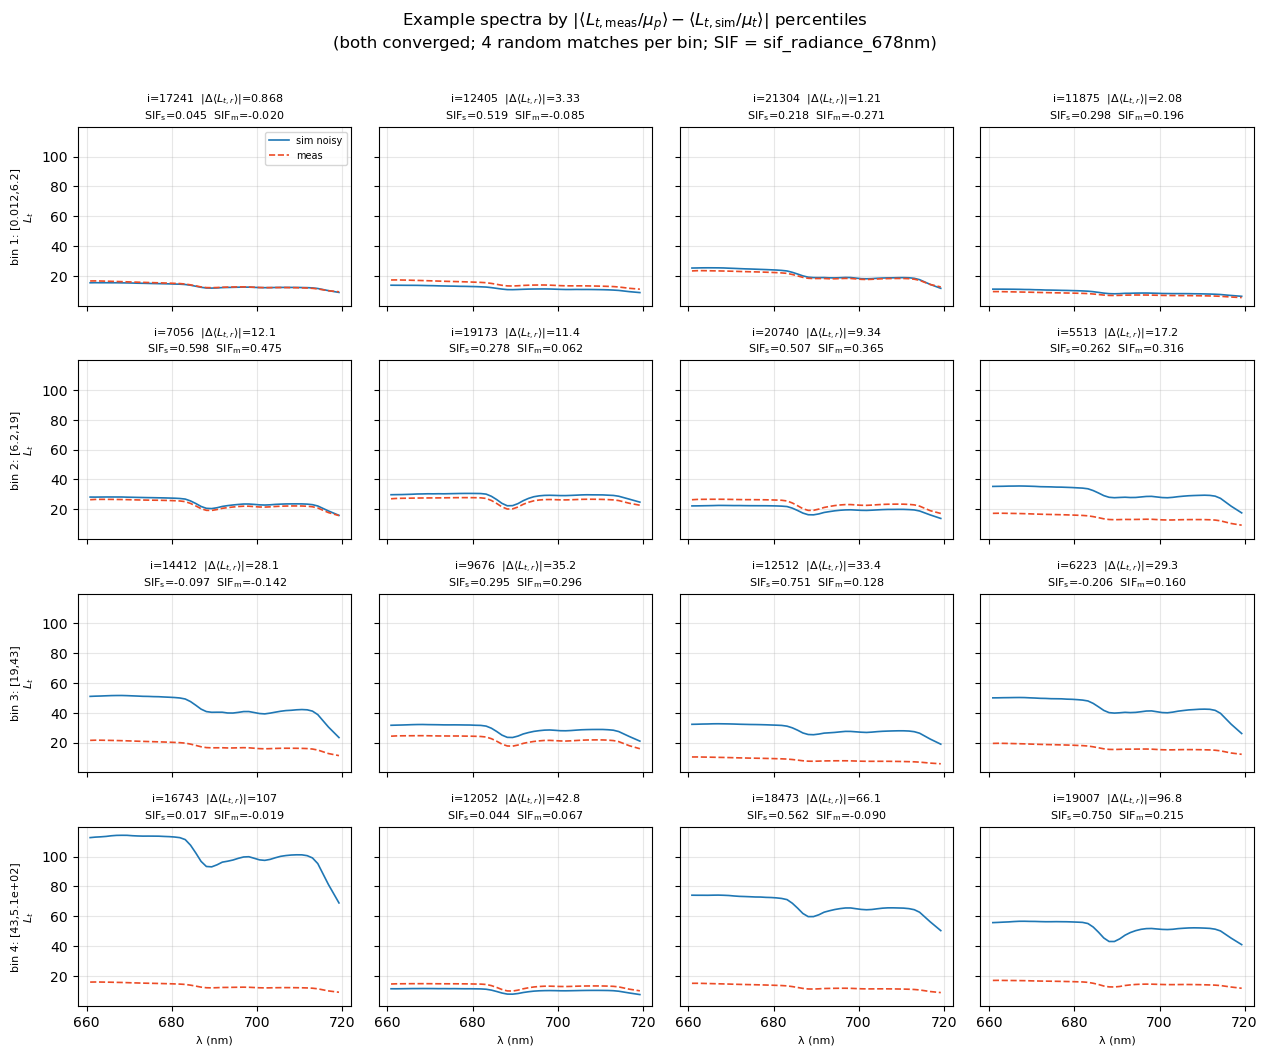

In [96]:
# Example spectra: 4 abs(Δ〈Lt_rescaled〉) percentile bins × 4 random both-converged matches
# Lt_rescaled = Lt / cos(SZA); sim uses sza_trop, meas uses sza_pace
# metric = |mean(Lt_meas/μ_p) − mean(Lt_sim/μ_t)|

RNG = np.random.default_rng(1)
N_BINS, N_PER_BIN = 4, 4

path_mu = matchup_nc  # from cell above: run_dir/products/matchup.nc
ds_mu = xr.open_dataset(path_mu)
band = np.asarray(ds_mu["band"].values, dtype=float)
lt_sim = np.asarray(ds_mu["lt_oci_sim_noisy"].values, dtype=float)   # (match, band)
lt_meas = np.asarray(ds_mu["lt_oci_meas"].values, dtype=float)
sza_p = np.asarray(ds_sim["sza_pace"].values, dtype=float)
sza_t = np.asarray(ds_sim["sza_trop"].values, dtype=float)
mu_p = np.maximum(np.cos(np.deg2rad(sza_p)), 1e-6)
mu_t = np.maximum(np.cos(np.deg2rad(sza_t)), 1e-6)

lt_sim_r = lt_sim / mu_t[:, None]
lt_meas_r = lt_meas / mu_p[:, None]
abs_dmean = np.abs(np.nanmean(lt_meas_r, axis=1) - np.nanmean(lt_sim_r, axis=1))

both = (
    conv_sim & conv_meas
    & np.isfinite(abs_dmean)
    & np.isfinite(lt_sim).all(axis=1)
    & np.isfinite(lt_meas).all(axis=1)
    & np.isfinite(sif_sim)
    & np.isfinite(sif_meas)
)
idx = np.flatnonzero(both)
print(f"both converged with finite spectra/|Δ〈Lt_r〉|/SIF: {idx.size:,} / {abs_dmean.size:,}")

qs = np.linspace(0, 100, N_BINS + 1)
edges = np.percentile(abs_dmean[idx], qs)

fig, axes = plt.subplots(
    N_BINS, N_PER_BIN, figsize=(3.2 * N_PER_BIN, 2.6 * N_BINS), sharex=True, sharey=True
)

for b in range(N_BINS):
    lo_e, hi_e = edges[b], edges[b + 1]
    if b < N_BINS - 1:
        in_bin = idx[(abs_dmean[idx] >= lo_e) & (abs_dmean[idx] < hi_e)]
    else:
        in_bin = idx[(abs_dmean[idx] >= lo_e) & (abs_dmean[idx] <= hi_e)]
    n_pick = min(N_PER_BIN, in_bin.size)
    pick = RNG.choice(in_bin, size=n_pick, replace=False) if n_pick else np.array([], dtype=int)
    print(
        f"bin {b+1}/{N_BINS}: |Δ〈Lt_r〉| ∈ [{lo_e:.4g}, {hi_e:.4g}]  "
        f"n={in_bin.size:,}  show={n_pick}"
    )

    for j in range(N_PER_BIN):
        ax = axes[b, j]
        if j >= n_pick:
            ax.set_visible(False)
            continue
        i = int(pick[j])
        ax.plot(band, lt_sim[i], color="#1f77b4", lw=1.2, label="sim noisy")
        ax.plot(band, lt_meas[i], color="#EC4B26", lw=1.2, ls="--", label="meas")
        ax.set_title(
            fr"i={i}  $|\Delta\langle L_{{t,r}}\rangle|$={abs_dmean[i]:.3g}"
            f"\nSIF$_\\mathrm{{s}}$={sif_sim[i]:.3f}  SIF$_\\mathrm{{m}}$={sif_meas[i]:.3f}",
            fontsize=8,
        )
        ax.grid(True, alpha=0.3)
        if b == N_BINS - 1:
            ax.set_xlabel("λ (nm)", fontsize=8)
        if j == 0:
            ax.set_ylabel(
                fr"bin {b+1}: [{lo_e:.2g},{hi_e:.2g}]" + "\n$L_t$",
                fontsize=8,
            )
        if b == 0 and j == 0:
            ax.legend(fontsize=7, loc="best")

fig.suptitle(
    r"Example spectra by $|\langle L_{t,\mathrm{meas}}/\mu_p\rangle-\langle L_{t,\mathrm{sim}}/\mu_t\rangle|$ percentiles"
    "\n(both converged; 4 random matches per bin; SIF = sif_radiance_678nm)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()
ds_mu.close()


,subset,metric,n,sim_mean,meas_mean,sim_med,meas_med,sim_p90,meas_p90,frac_meas_gt_sim
0,all finite,reduced_chi2,22262,1.1040,0.4788,1.0649,0.2956,1.5881,0.8342,0.0814
1,all finite,rmse,22262,0.0107,0.0057,0.0099,0.0048,0.0160,0.0091,0.0789
2,both converged,reduced_chi2,2034,1.1413,0.4924,1.1073,0.3105,1.6334,0.9437,0.0900
3,both converged,rmse,2034,0.0130,0.0062,0.0122,0.0053,0.0188,0.0100,0.0708


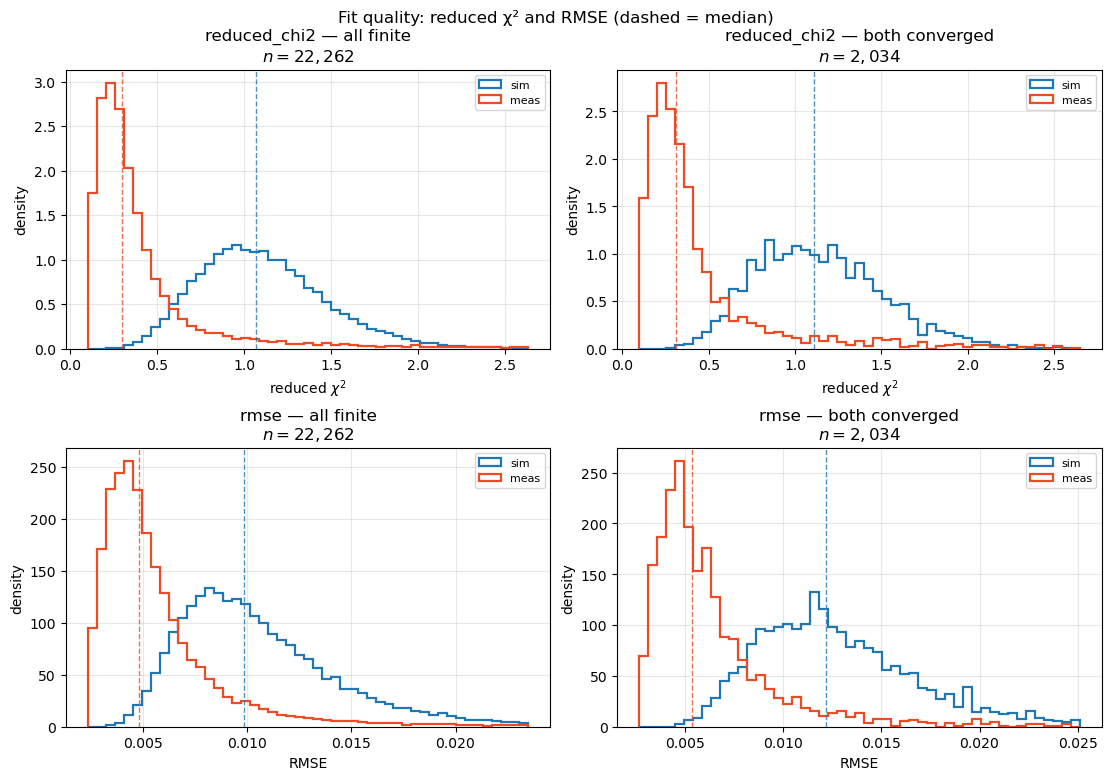

In [97]:
# comparing reduced chi2 and rmse (meas vs sim)
# subsets: all finite pairs | both converged

chi2_sim = np.asarray(ds_sim["reduced_chi2"].values, dtype=float)
chi2_meas = np.asarray(ds_meas["reduced_chi2"].values, dtype=float)
rmse_sim = np.asarray(ds_sim["rmse"].values, dtype=float)
rmse_meas = np.asarray(ds_meas["rmse"].values, dtype=float)

masks = {
    "all finite": (
        np.isfinite(chi2_sim) & np.isfinite(chi2_meas)
        & np.isfinite(rmse_sim) & np.isfinite(rmse_meas)
    ),
    "both converged": (
        np.isfinite(chi2_sim) & np.isfinite(chi2_meas)
        & np.isfinite(rmse_sim) & np.isfinite(rmse_meas)
        & conv_sim & conv_meas
    ),
}

rows = []
for label, m in masks.items():
    for name, a_sim, a_meas in [
        ("reduced_chi2", chi2_sim, chi2_meas),
        ("rmse", rmse_sim, rmse_meas),
    ]:
        xs, xm = a_sim[m], a_meas[m]
        rows.append(
            dict(
                subset=label,
                metric=name,
                n=int(m.sum()),
                sim_mean=float(np.mean(xs)),
                meas_mean=float(np.mean(xm)),
                sim_med=float(np.median(xs)),
                meas_med=float(np.median(xm)),
                sim_p90=float(np.percentile(xs, 90)),
                meas_p90=float(np.percentile(xm, 90)),
                frac_meas_gt_sim=float(np.mean(xm > xs)),
            )
        )
df_fit = pd.DataFrame(rows)
display(df_fit.round(4))

# histograms: rows = metric, cols = subset
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)
for col, (label, m) in enumerate(masks.items()):
    for row, (name, a_sim, a_meas, xlab) in enumerate(
        [
            ("reduced_chi2", chi2_sim, chi2_meas, r"reduced $\chi^2$"),
            ("rmse", rmse_sim, rmse_meas, "RMSE"),
        ]
    ):
        ax = axes[row, col]
        xs, xm = a_sim[m], a_meas[m]
        pool = np.concatenate([xs, xm])
        lo, hi = np.nanpercentile(pool, [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.nanmin(pool)), float(np.nanmax(pool) + 1e-6)
        bins = np.linspace(lo, hi, 50)
        ax.hist(xs, bins=bins, histtype="step", density=True, lw=1.6, color="#1f77b4", label="sim")
        ax.hist(xm, bins=bins, histtype="step", density=True, lw=1.6, color="#EC4B26", label="meas")
        ax.axvline(np.median(xs), color="#1f77b4", ls="--", lw=1.0, alpha=0.8)
        ax.axvline(np.median(xm), color="#EC4B26", ls="--", lw=1.0, alpha=0.8)
        ax.set_title(f"{name} — {label}\n$n={m.sum():,}$")
        ax.set_xlabel(xlab)
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

fig.suptitle("Fit quality: reduced χ² and RMSE (dashed = median)", y=1.02)
plt.show()


## <b> Sensitivity to viewing geometry? <b>

all finite: n=22,262 / 22,262


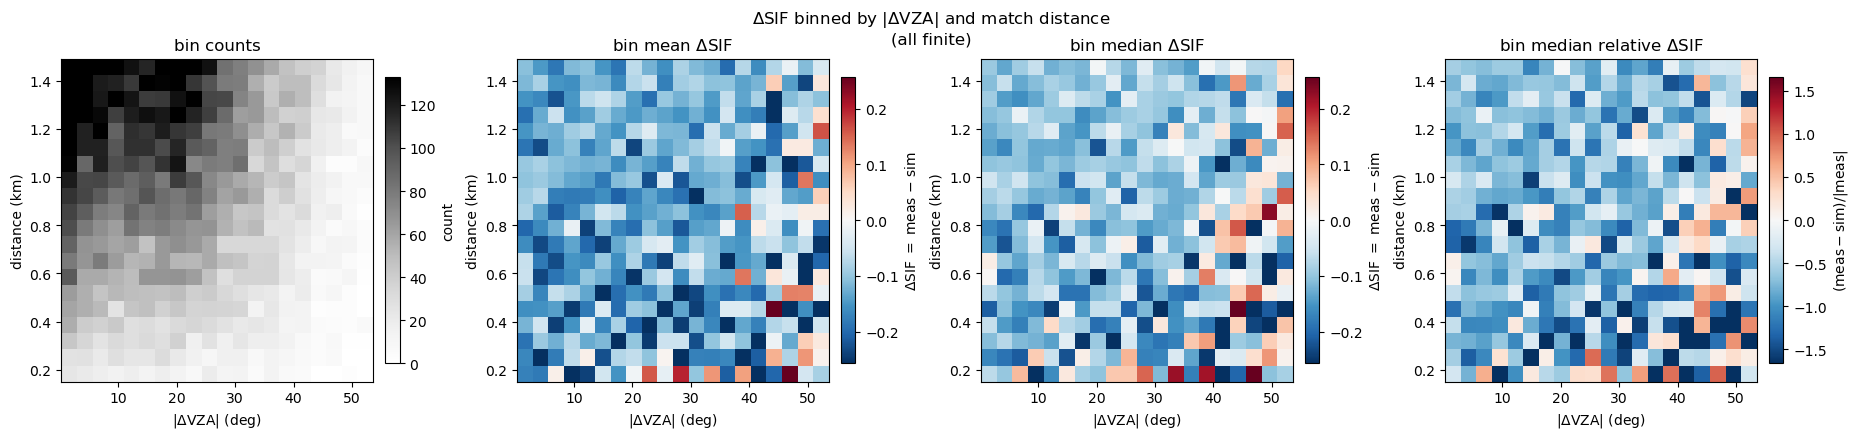

color vmax (±95th |stat|): 0.2571; rel vmax: 1.664
occupied bins: 400 / 400


In [98]:
# 2D binned ΔSIF vs |ΔVZA| and match distance
# ΔSIF = sif_meas − sif_sim; color = mean / median in each (|ΔVZA|, dist_km) bin
# rel ΔSIF = (meas − sim) / max(|meas|, eps)

# True → both converged; False → all finite pairs (ignore converged)
USE_CONVERGED_ONLY = False

path_mu = matchup_nc  # run_dir/products/matchup.nc (not under root_dir)
ds_mu = xr.open_dataset(path_mu)
dist_km = np.asarray(ds_mu["dist_km"].values, dtype=float)
ds_mu.close()

vza_p = np.asarray(ds_sim["vza_pace"].values, dtype=float)
vza_t = np.asarray(ds_sim["vza_trop"].values, dtype=float)
abs_dvza = np.abs(vza_p - vza_t)
dSIF = sif_meas - sif_sim
eps = 1e-6
rel_dSIF = dSIF / np.maximum(np.abs(sif_meas), eps)

mask = (
    np.isfinite(dSIF)
    & np.isfinite(rel_dSIF)
    & np.isfinite(abs_dvza)
    & np.isfinite(dist_km)
)
if USE_CONVERGED_ONLY:
    mask &= conv_sim & conv_meas

x = abs_dvza[mask]
y = dist_km[mask]
z = dSIF[mask]
z_rel = rel_dSIF[mask]
sel = "both converged" if USE_CONVERGED_ONLY else "all finite"
print(f"{sel}: n={mask.sum():,} / {mask.size:,}")

# Adaptive bins from data percentiles + fixed edges
nx, ny = 20, 20
x_edges = np.linspace(np.percentile(x, 1), np.percentile(x, 99), nx + 1)
y_edges = np.linspace(np.percentile(y, 1), np.percentile(y, 99), ny + 1)

ix = np.digitize(x, x_edges) - 1
iy = np.digitize(y, y_edges) - 1
valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
ix, iy, z, z_rel = ix[valid], iy[valid], z[valid], z_rel[valid]

cnt = np.zeros((ny, nx), dtype=float)
from collections import defaultdict
bucket = defaultdict(list)
bucket_rel = defaultdict(list)
for i, j, zz, zr in zip(iy, ix, z, z_rel):
    cnt[i, j] += 1
    bucket[(i, j)].append(zz)
    bucket_rel[(i, j)].append(zr)

mean_z = np.full((ny, nx), np.nan)
med_z = np.full((ny, nx), np.nan)
med_rel = np.full((ny, nx), np.nan)
for (i, j), vals in bucket.items():
    arr = np.asarray(vals, dtype=float)
    mean_z[i, j] = arr.mean()
    med_z[i, j] = np.median(arr)
    med_rel[i, j] = np.median(bucket_rel[(i, j)])

pool = np.concatenate([mean_z[np.isfinite(mean_z)], med_z[np.isfinite(med_z)]])
vmax = float(np.nanpercentile(np.abs(pool), 95)) if pool.size else 1.0
vmax = max(vmax, 1e-6)

pool_rel = med_rel[np.isfinite(med_rel)]
vmax_rel = float(np.nanpercentile(np.abs(pool_rel), 95)) if pool_rel.size else 1.0
vmax_rel = max(vmax_rel, 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(18.5, 4.0), constrained_layout=True)

ax = axes[0]
pcm = ax.pcolormesh(x_edges, y_edges, cnt, cmap="Greys", shading="flat")
pcm.set_clim(0, np.percentile(cnt[cnt > 0], 95) if (cnt > 0).any() else 1)
cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("count")
ax.set_title("bin counts")
ax.set_xlabel(r"$|\Delta$VZA$|$ (deg)")
ax.set_ylabel(r"distance (km)")

for ax, arr, title, vmx, clab in [
    (axes[1], mean_z, r"bin mean $\Delta$SIF", vmax, r"$\Delta$SIF $=$ meas $-$ sim"),
    (axes[2], med_z, r"bin median $\Delta$SIF", vmax, r"$\Delta$SIF $=$ meas $-$ sim"),
    (
        axes[3],
        med_rel,
        r"bin median relative $\Delta$SIF",
        vmax_rel,
        r"$(\mathrm{meas}-\mathrm{sim})/|\mathrm{meas}|$",
    ),
]:
    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        arr,
        cmap="RdBu_r",
        shading="flat",
        vmin=-vmx,
        vmax=vmx,
    )
    cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(clab)
    ax.set_title(title)
    ax.set_xlabel(r"$|\Delta$VZA$|$ (deg)")
    ax.set_ylabel(r"distance (km)")

fig.suptitle(
    rf"$\Delta$SIF binned by $|\Delta$VZA| and match distance"
    f"\n({sel})",
    y=1.06,
)
plt.show()

print(f"color vmax (±95th |stat|): {vmax:.4g}; rel vmax: {vmax_rel:.4g}")
print(f"occupied bins: {int(np.isfinite(mean_z).sum())} / {ny * nx}")


both converged: n=2,034 / 22,262


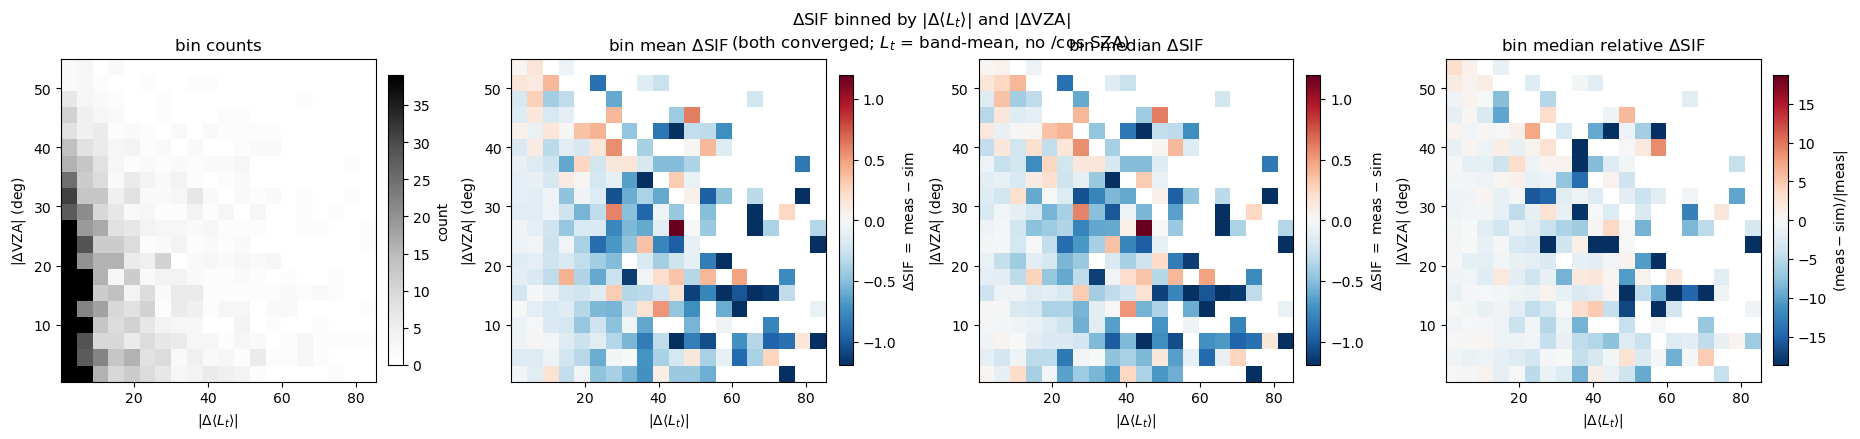

color vmax (±95th |stat|): 1.194; rel vmax: 18.65
occupied bins: 250 / 400


In [99]:
# 2D binned ΔSIF vs |Δ〈Lt〉| and |ΔVZA|
# |Δ〈Lt〉| = |mean(Lt_meas) − mean(Lt_sim_noisy)| across bands (no /cos SZA)
# ΔSIF = sif_meas − sif_sim; rel = ΔSIF / max(|meas|, eps)

# True → both converged; False → all finite pairs (ignore converged)
USE_CONVERGED_ONLY = True

path_mu = matchup_nc  # run_dir/products/matchup.nc (not under root_dir)
ds_mu = xr.open_dataset(path_mu)
lt_sim = np.asarray(ds_mu["lt_oci_sim_noisy"].values, dtype=float)  # (match, band)
lt_meas = np.asarray(ds_mu["lt_oci_meas"].values, dtype=float)
ds_mu.close()

vza_p = np.asarray(ds_sim["vza_pace"].values, dtype=float)
vza_t = np.asarray(ds_sim["vza_trop"].values, dtype=float)
abs_dvza = np.abs(vza_p - vza_t)
abs_dlt = np.abs(np.nanmean(lt_meas, axis=1) - np.nanmean(lt_sim, axis=1))

dSIF = sif_meas - sif_sim
eps = 1e-6
rel_dSIF = dSIF / np.maximum(np.abs(sif_meas), eps)

mask = (
    np.isfinite(dSIF)
    & np.isfinite(rel_dSIF)
    & np.isfinite(abs_dvza)
    & np.isfinite(abs_dlt)
    & np.isfinite(lt_sim).all(axis=1)
    & np.isfinite(lt_meas).all(axis=1)
)
if USE_CONVERGED_ONLY:
    mask &= conv_sim & conv_meas

x = abs_dlt[mask]
y = abs_dvza[mask]
z = dSIF[mask]
z_rel = rel_dSIF[mask]
sel = "both converged" if USE_CONVERGED_ONLY else "all finite"
print(f"{sel}: n={mask.sum():,} / {mask.size:,}")

nx, ny = 20, 20
x_edges = np.linspace(np.percentile(x, 1), np.percentile(x, 99), nx + 1)
y_edges = np.linspace(np.percentile(y, 1), np.percentile(y, 99), ny + 1)

ix = np.digitize(x, x_edges) - 1
iy = np.digitize(y, y_edges) - 1
valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
ix, iy, z, z_rel = ix[valid], iy[valid], z[valid], z_rel[valid]

cnt = np.zeros((ny, nx), dtype=float)
from collections import defaultdict
bucket = defaultdict(list)
bucket_rel = defaultdict(list)
for i, j, zz, zr in zip(iy, ix, z, z_rel):
    cnt[i, j] += 1
    bucket[(i, j)].append(zz)
    bucket_rel[(i, j)].append(zr)

mean_z = np.full((ny, nx), np.nan)
med_z = np.full((ny, nx), np.nan)
med_rel = np.full((ny, nx), np.nan)
for (i, j), vals in bucket.items():
    arr = np.asarray(vals, dtype=float)
    mean_z[i, j] = arr.mean()
    med_z[i, j] = np.median(arr)
    med_rel[i, j] = np.median(bucket_rel[(i, j)])

pool = np.concatenate([mean_z[np.isfinite(mean_z)], med_z[np.isfinite(med_z)]])
vmax = float(np.nanpercentile(np.abs(pool), 95)) if pool.size else 1.0
vmax = max(vmax, 1e-6)
pool_rel = med_rel[np.isfinite(med_rel)]
vmax_rel = float(np.nanpercentile(np.abs(pool_rel), 95)) if pool_rel.size else 1.0
vmax_rel = max(vmax_rel, 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(18.5, 4.0), constrained_layout=True)

ax = axes[0]
pcm = ax.pcolormesh(x_edges, y_edges, cnt, cmap="Greys", shading="flat")
pcm.set_clim(0, np.percentile(cnt[cnt > 0], 95) if (cnt > 0).any() else 1)
cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("count")
ax.set_title("bin counts")
ax.set_xlabel(r"$|\Delta\langle L_t\rangle|$")
ax.set_ylabel(r"$|\Delta$VZA$|$ (deg)")

for ax, arr, title, vmx, clab in [
    (axes[1], mean_z, r"bin mean $\Delta$SIF", vmax, r"$\Delta$SIF $=$ meas $-$ sim"),
    (axes[2], med_z, r"bin median $\Delta$SIF", vmax, r"$\Delta$SIF $=$ meas $-$ sim"),
    (
        axes[3],
        med_rel,
        r"bin median relative $\Delta$SIF",
        vmax_rel,
        r"$(\mathrm{meas}-\mathrm{sim})/|\mathrm{meas}|$",
    ),
]:
    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        arr,
        cmap="RdBu_r",
        shading="flat",
        vmin=-vmx,
        vmax=vmx,
    )
    cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(clab)
    ax.set_title(title)
    ax.set_xlabel(r"$|\Delta\langle L_t\rangle|$")
    ax.set_ylabel(r"$|\Delta$VZA$|$ (deg)")

fig.suptitle(
    r"$\Delta$SIF binned by $|\Delta\langle L_t\rangle|$ and $|\Delta$VZA|"
    f"\n({sel}; $L_t$ = band-mean, no /cos SZA)",
    y=1.06,
)
plt.show()

print(f"color vmax (±95th |stat|): {vmax:.4g}; rel vmax: {vmax_rel:.4g}")
print(f"occupied bins: {int(np.isfinite(mean_z).sum())} / {ny * nx}")


<div style="background-color:#FFF8E1; border:1px solid #FFD54F; border-left:6px solid #F9A825; border-radius:6px; padding:14px 16px; margin:8px 0; color:#333;">

<strong>Note — Why is meas SIF systematically lower than sim SIF?</strong>

<p>It is <b>not always</b> lower (for <code>nPC=15, npoly=5</code>, meas &lt; sim in ~60–63% of pairs), but the <b>mean bias is one-sided</b>.</p>

<p><b>What the numbers show (both-converged)</b></p>

<table style="border-collapse:collapse; margin:6px 0 10px 0;">
<tr><th style="text-align:left; padding:2px 10px;">quantity</th><th>meas</th><th>sim</th><th>meas/sim</th></tr>
<tr><td style="padding:2px 10px;">mean ⟨L<sub>t</sub>⟩</td><td>lower</td><td>higher</td><td>~0.55</td></tr>
<tr><td style="padding:2px 10px;">mean SIF @ 678 nm</td><td>~0.11</td><td>~0.29</td><td>~0.38</td></tr>
<tr><td style="padding:2px 10px;">median SIF / ⟨L<sub>t</sub>⟩</td><td>~0.0068</td><td>~0.011</td><td>~0.64</td></tr>
</table>

<p>So both the <b>absolute continuum</b> and the <b>fractional</b> in-filling (SIF / continuum) are weaker on real OCI.</p>

<p><b>Main driver: absolute continuum / radiance mismatch.</b>
Retrieved <code>sif_radiance_678nm</code> is an <b>absolute radiance</b>. In the forward model it is an additive fill-in on top of reflected continuum ∝ F<sub>0</sub> μ ρ. Spectra with similar fractional SIF but different absolute continuum yield radiance SIF that roughly tracks continuum:</p>

$$\mathrm{SIF}_\mathrm{rad} \sim f \cdot L_t^\mathrm{cont}$$

<p>Paths differ:</p>
<ul>
<li><b>meas</b>: PACE ρ<sub>t</sub> × F<sub>0</sub> × μ / (π esd)</li>
<li><b>sim</b>: TROPOMI radiance → SVD denoise → RSR (no PACE radiometric / albedo rescaling)</li>
</ul>
<p>RSR transfers spectral shape, not absolute calibration. Simulated OCI L<sub>t</sub> is systematically brighter, so sim radiance SIF tends to come out larger. Geometry (|ΔVZA|, ΔSZA) is only weakly correlated with ΔSIF.</p>

<p><b>What continuum rescaling is (and is not).</b>
Post-hoc</p>

$$\mathrm{SIF}_\mathrm{sim}^\ast = \mathrm{SIF}_\mathrm{sim}\times\frac{\langle L_t^\mathrm{meas}\rangle}{\langle L_t^\mathrm{sim}\rangle}$$

<p>is a <b>diagnostic</b>, not a physical retrieval step — it asks whether continua matched would leave residual ΔSIF. That cut mean bias from about <b>−0.18 → −0.07</b> (~⅔). The rest is fractional SIF / spectral contrast (noisier real OCI, SVD-smoothed sim, possible calibration residuals, selection).</p>

<p><b>Better checks:</b> (1) compare SIF / ⟨L<sub>t</sub>⟩; (2) normalize both spectra the same way before retrieval; (3) fix absolute level in the simulator, then re-retrieve.</p>

</div>


## <b>Sensitivity to state vector? </b>

In [100]:
# State-vector sensitivity: multi-config runs under sif_retrieval/
# (older / parallel nPC–npoly suite; not the chi2_correct_retrieval subtree)
root_dir = os.path.join(run_dir, "sif_retrieval")

test_names = [
    "sif_retrieval_nPC_15_npoly_5/",
    "sif_retrieval_nPC_15_npoly_10/",
    "sif_retrieval_nPC_10_npoly_5/",
    "sif_retrieval_nPC_20_npoly_5/",
]

label_names = [
    "nPC=15, npoly=5",
    "nPC=15, npoly=10",
    "nPC=10, npoly=5",
    "nPC=20, npoly=5",
]


In [101]:
# Load sif_radiance_678nm + convergence for each (nPC, npoly) run
runs = []
for name, label in zip(test_names, label_names):
    p_sim = os.path.join(root_dir, name, "matchup_sif_sim_noisy.nc")
    p_meas = os.path.join(root_dir, name, "matchup_sif_meas.nc")
    if not (os.path.isfile(p_sim) and os.path.isfile(p_meas)):
        print(f"SKIP missing: {label}\n  {p_sim}\n  {p_meas}")
        continue
    ds_s = xr.open_dataset(p_sim)
    ds_m = xr.open_dataset(p_meas)
    sif_s = np.asarray(ds_s["sif_radiance_678nm"].values, dtype=float)
    sif_m = np.asarray(ds_m["sif_radiance_678nm"].values, dtype=float)
    conv_s = np.asarray(ds_s["converged"].values).astype(bool)
    conv_m = np.asarray(ds_m["converged"].values).astype(bool)
    ds_s.close()
    ds_m.close()
    runs.append(
        dict(
            name=name,
            label=label,
            sif_sim=sif_s,
            sif_meas=sif_m,
            conv_sim=conv_s,
            conv_meas=conv_m,
        )
    )
    print(
        f"{label}: n={sif_m.size:,}  "
        f"meas_conv={conv_m.sum():,}  sim_conv={conv_s.sum():,}  "
        f"both={ (conv_m & conv_s).sum():,}"
    )

assert runs, "no retrieval products found"


nPC=15, npoly=5: n=22,262  meas_conv=7,031  sim_conv=5,709  both=2,038
nPC=15, npoly=10: n=22,262  meas_conv=77  sim_conv=409  both=3
nPC=10, npoly=5: n=22,262  meas_conv=15,941  sim_conv=15,102  both=11,482
nPC=20, npoly=5: n=22,262  meas_conv=632  sim_conv=633  both=26


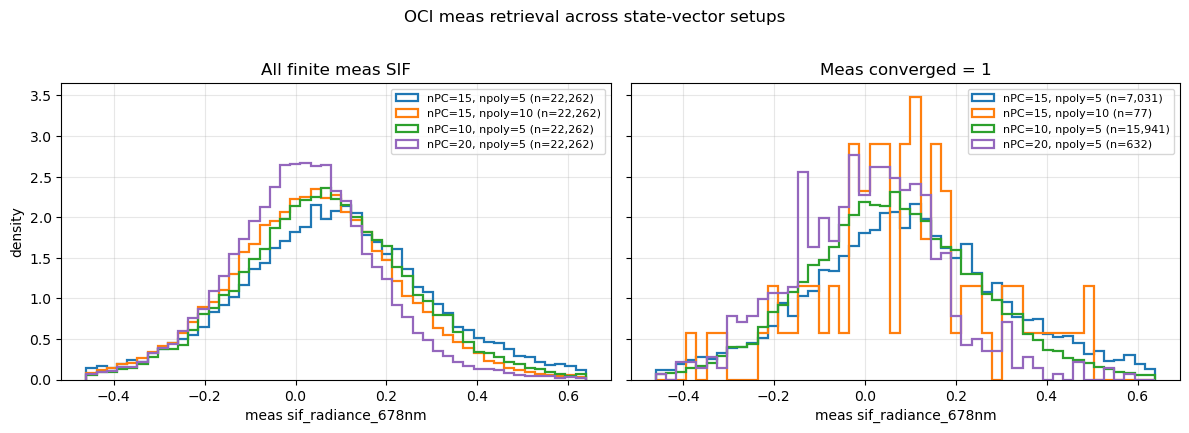

In [102]:
# Meas SIF histograms across configs (all finite | meas converged)
colors = plt.cm.tab10(np.linspace(0, 0.4, len(runs)))

pool = np.concatenate(
    [
        r["sif_meas"][np.isfinite(r["sif_meas"])]
        for r in runs
        if np.isfinite(r["sif_meas"]).any()
    ]
)
lo, hi = np.nanpercentile(pool, [1, 99])
bins = np.linspace(lo, hi, 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, use_conv, title in [
    (axes[0], False, "All finite meas SIF"),
    (axes[1], True, "Meas converged = 1"),
]:
    for r, c in zip(runs, colors):
        sif_m = r["sif_meas"]
        mask = np.isfinite(sif_m)
        if use_conv:
            mask &= r["conv_meas"]
        ax.hist(
            sif_m[mask],
            bins=bins,
            histtype="step",
            density=True,
            lw=1.6,
            color=c,
            label=f"{r['label']} (n={mask.sum():,})",
        )
    ax.set_xlabel(r"meas sif_radiance_678nm")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel("density")
fig.suptitle("OCI meas retrieval across state-vector setups", y=1.02)
plt.tight_layout()
plt.show()


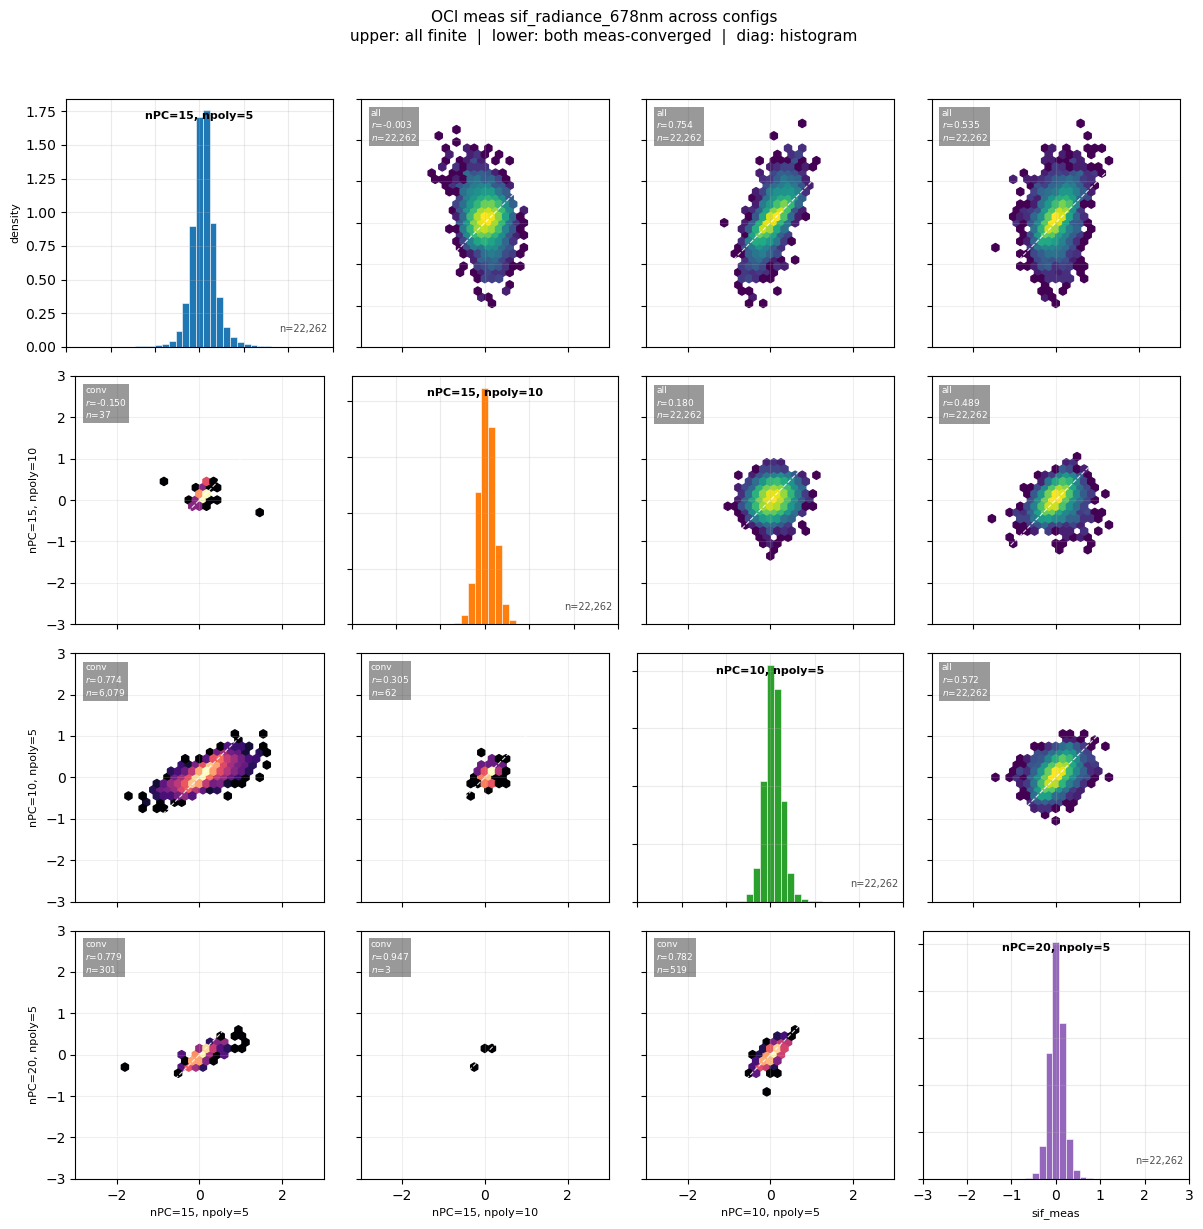

In [103]:
# Pairwise sif_meas: upper=all finite hexbin, lower=both meas-converged hexbin, diag=hist
n = len(runs)
labels = [r["label"] for r in runs]
meas = [r["sif_meas"] for r in runs]
conv = [r["conv_meas"] for r in runs]

lo, hi = -3.0, 3.0
bins = np.linspace(lo, hi, 40)
colors = plt.cm.tab10(np.linspace(0, 0.4, n))

fig, axes = plt.subplots(n, n, figsize=(3.0 * n, 3.0 * n))
if n == 1:
    axes = np.asarray([[axes]])

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        # Diagonal: histogram of this config's meas SIF
        if i == j:
            y = meas[i]
            m = np.isfinite(y)
            ax.hist(
                y[m],
                bins=bins,
                color=colors[i],
                edgecolor="white",
                linewidth=0.4,
                density=True,
            )
            ax.set_xlim(lo, hi)
            ax.text(
                0.50,
                0.95,
                labels[i],
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=8,
                fontweight="bold",
            )
            ax.text(
                0.98,
                0.05,
                f"n={m.sum():,}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=7,
                color="0.3",
            )
            ax.grid(True, alpha=0.25)
            if i == n - 1:
                ax.set_xlabel(r"sif_meas", fontsize=8)
            else:
                ax.tick_params(labelbottom=False)
            if j == 0:
                ax.set_ylabel("density", fontsize=8)
            else:
                ax.tick_params(labelleft=False)
            continue

        # Off-diagonal hexbin: column j = x, row i = y
        x, y = meas[j], meas[i]
        if i < j:
            # upper triangle: all finite
            m = np.isfinite(x) & np.isfinite(y)
            tag = "all"
            cmap = "viridis"
        else:
            # lower triangle: both configs meas-converged
            m = np.isfinite(x) & np.isfinite(y) & conv[j] & conv[i]
            tag = "conv"
            cmap = "magma"

        xx, yy = x[m], y[m]
        if xx.size:
            ax.hexbin(xx, yy, gridsize=35, mincnt=1, bins="log", cmap=cmap, extent=[lo, hi, lo, hi])
            r = float(np.corrcoef(xx, yy)[0, 1]) if xx.size > 1 else np.nan
            ax.text(
                0.04,
                0.96,
                f"{tag}\n$r$={r:.3f}\n$n$={xx.size:,}",
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=6.5,
                color="w",
                bbox=dict(facecolor="k", alpha=0.4, edgecolor="none", pad=1.5),
            )
        ax.plot([lo, hi], [lo, hi], color="w", ls="--", lw=0.8, alpha=0.85)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=8)
        else:
            ax.tick_params(labelbottom=False)
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=8)
        else:
            ax.tick_params(labelleft=False)

fig.suptitle(
    "OCI meas sif_radiance_678nm across configs\n"
    r"upper: all finite  |  lower: both meas-converged  |  diag: histogram",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


,setup,mask,n,meas_mean,sim_mean,dSIF_mean,dSIF_std,dSIF_med,rel_med,rmse,r
0,"nPC=15, npoly=5",all_finite,22262,0.0905,0.2218,-0.1313,0.4585,-0.0986,-0.6968,0.4769,0.0276
1,"nPC=15, npoly=5",both_conv,2038,0.1080,0.2877,-0.1796,0.5331,-0.1438,-0.8377,0.5626,0.0431
2,"nPC=15, npoly=10",all_finite,22262,0.0395,0.0514,-0.0118,0.4974,-0.0067,-0.0511,0.4976,0.0072
3,"nPC=15, npoly=10",both_conv,3,0.0465,-0.0610,0.1075,0.6726,0.5213,4.2914,0.6811,0.9994
4,"nPC=10, npoly=5",all_finite,22262,0.0663,0.2653,-0.1990,0.4084,-0.1544,-1.2925,0.4543,0.0211
5,"nPC=10, npoly=5",both_conv,11482,0.0630,0.3045,-0.2414,0.4007,-0.1944,-1.5781,0.4678,0.0324
6,"nPC=20, npoly=5",all_finite,22262,0.0153,0.0846,-0.0693,0.4344,-0.0597,-0.5440,0.4399,0.0186
7,"nPC=20, npoly=5",both_conv,26,0.0107,-0.1788,0.1895,0.7880,0.0201,0.2952,0.8104,0.3206


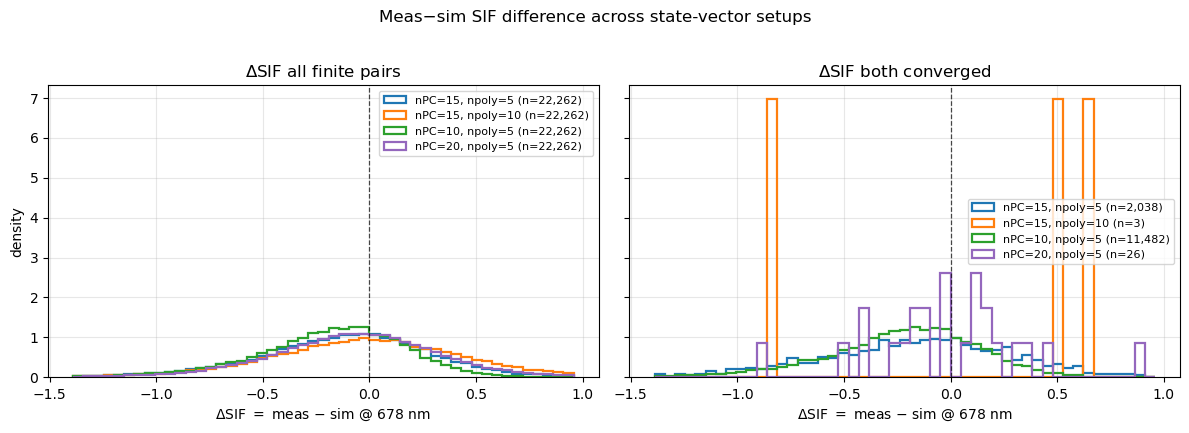

In [104]:
# ΔSIF = meas − sim distributions + paired summary stats (all finite | both converged)
eps = 1e-6
rows = []
diff_pools = []

for r in runs:
    x, y = r["sif_sim"], r["sif_meas"]
    m_all = np.isfinite(x) & np.isfinite(y)
    m_ok = m_all & r["conv_sim"] & r["conv_meas"]
    for mask, tag in [(m_all, "all_finite"), (m_ok, "both_conv")]:
        d = y[mask] - x[mask]
        rel = d / np.maximum(np.abs(y[mask]), eps)
        rows.append(
            dict(
                setup=r["label"],
                mask=tag,
                n=int(mask.sum()),
                meas_mean=float(np.nanmean(y[mask])) if mask.any() else np.nan,
                sim_mean=float(np.nanmean(x[mask])) if mask.any() else np.nan,
                dSIF_mean=float(np.nanmean(d)) if d.size else np.nan,
                dSIF_std=float(np.nanstd(d)) if d.size else np.nan,
                dSIF_med=float(np.nanmedian(d)) if d.size else np.nan,
                rel_med=float(np.nanmedian(rel)) if rel.size else np.nan,
                rmse=float(np.sqrt(np.nanmean(d**2))) if d.size else np.nan,
                r=float(np.corrcoef(x[mask], y[mask])[0, 1]) if mask.sum() > 1 else np.nan,
            )
        )
        if d.size:
            diff_pools.append(d)

df = pd.DataFrame(rows)
display(df.round(4))

pool = np.concatenate(diff_pools) if diff_pools else np.array([0.0])
dlo, dhi = np.nanpercentile(pool, [1, 99])
dbins = np.linspace(dlo, dhi, 50)
colors = plt.cm.tab10(np.linspace(0, 0.4, len(runs)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, tag, title in [
    (axes[0], "all_finite", r"$\Delta$SIF all finite pairs"),
    (axes[1], "both_conv", r"$\Delta$SIF both converged"),
]:
    for r, c in zip(runs, colors):
        x, y = r["sif_sim"], r["sif_meas"]
        m = np.isfinite(x) & np.isfinite(y)
        if tag == "both_conv":
            m &= r["conv_sim"] & r["conv_meas"]
        d = y[m] - x[m]
        ax.hist(
            d,
            bins=dbins,
            histtype="step",
            density=True,
            lw=1.6,
            color=c,
            label=f"{r['label']} (n={m.sum():,})",
        )
    ax.axvline(0, color="k", ls="--", lw=0.9, alpha=0.7)
    ax.set_xlabel(r"$\Delta$SIF $=$ meas $-$ sim @ 678 nm")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel("density")
fig.suptitle("Meas−sim SIF difference across state-vector setups", y=1.02)
plt.tight_layout()
plt.show()


## <b>Comparison w/ PACE & TROPOMI pipeline retrieval</b>

In [105]:
matchup_sif = xr.open_dataset(
    "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/TROPOMI_OCI_colocation_data/runs/july2025_d01-31/matches/matchup_independent_sif.nc"
)

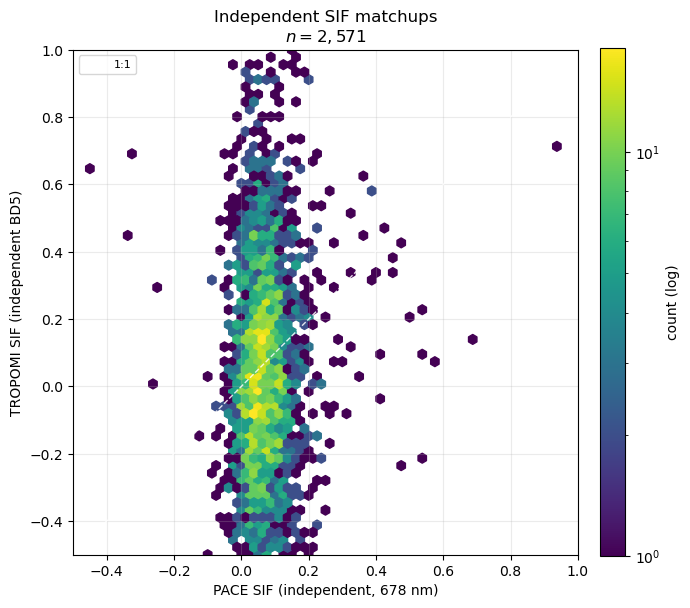

In [106]:
# plot matches (independent PACE vs TROPOMI SIF)
sif_pace = np.asarray(matchup_sif["sif_pace_678nm"].values, dtype=float)
sif_trop = np.asarray(matchup_sif["sif_trop"].values, dtype=float)
m = np.isfinite(sif_pace) & np.isfinite(sif_trop)
if "pace_found" in matchup_sif and "trop_found" in matchup_sif:
    m &= np.asarray(matchup_sif["pace_found"].values).astype(bool)
    m &= np.asarray(matchup_sif["trop_found"].values).astype(bool)

x, y = sif_pace[m], sif_trop[m]
xlim = ylim = (-0.5, 1.0)

fig, ax = plt.subplots(figsize=(7, 6.5))
hb = ax.hexbin(
    x, y,
    gridsize=60,
    mincnt=1,
    bins="log",
    cmap="viridis",
    extent=(*xlim, *ylim),
)
ax.plot(xlim, ylim, "w--", lw=1.0, alpha=0.85, label="1:1")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("PACE SIF (independent, 678 nm)")
ax.set_ylabel("TROPOMI SIF (independent BD5)")
ax.set_title(f"Independent SIF matchups\n$n={x.size:,}$")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", fontsize=8)
cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("count (log)")
plt.tight_layout()
plt.show()


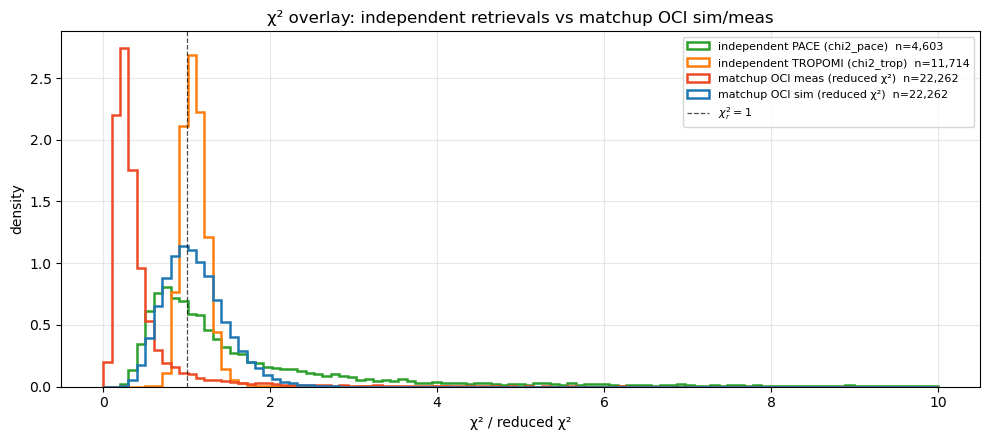

In [107]:
# χ² distributions: independent PACE/TROPOMI vs matchup OCI meas / OCI sim
chi2_pace = np.asarray(matchup_sif["chi2_pace"].values, dtype=float)
chi2_trop = np.asarray(matchup_sif["chi2_trop"].values, dtype=float)
chi2_oci_sim = np.asarray(ds_sim["reduced_chi2"].values, dtype=float)
chi2_oci_meas = np.asarray(ds_meas["reduced_chi2"].values, dtype=float)

m_pace = np.isfinite(chi2_pace)
m_trop = np.isfinite(chi2_trop)
if "pace_found" in matchup_sif:
    m_pace &= np.asarray(matchup_sif["pace_found"].values).astype(bool)
if "trop_found" in matchup_sif:
    m_trop &= np.asarray(matchup_sif["trop_found"].values).astype(bool)
m_sim = np.isfinite(chi2_oci_sim)
m_meas = np.isfinite(chi2_oci_meas)

bins = np.linspace(0, 10, 100)
series = [
    (chi2_pace[m_pace], "independent PACE (chi2_pace)", "#2ca02c"),
    (chi2_trop[m_trop], "independent TROPOMI (chi2_trop)", "#ff7f0e"),
    (chi2_oci_meas[m_meas], "matchup OCI meas (reduced χ²)", "#EC4B26"),
    (chi2_oci_sim[m_sim], "matchup OCI sim (reduced χ²)", "#1f77b4"),
]

fig, ax = plt.subplots(figsize=(10, 4.5))
for vals, label, color in series:
    ax.hist(
        vals,
        bins=bins,
        histtype="step",
        density=True,
        lw=1.8,
        color=color,
        label=f"{label}  n={vals.size:,}",
    )
ax.axvline(1.0, color="k", ls="--", lw=0.9, alpha=0.7, label=r"$\chi^2_r=1$")
ax.set_xlabel(r"χ² / reduced χ²")
ax.set_ylabel("density")
ax.set_title("χ² overlay: independent retrievals vs matchup OCI sim/meas")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()


both converged indep∩sim:  n=824
both converged indep∩meas: n=1,004


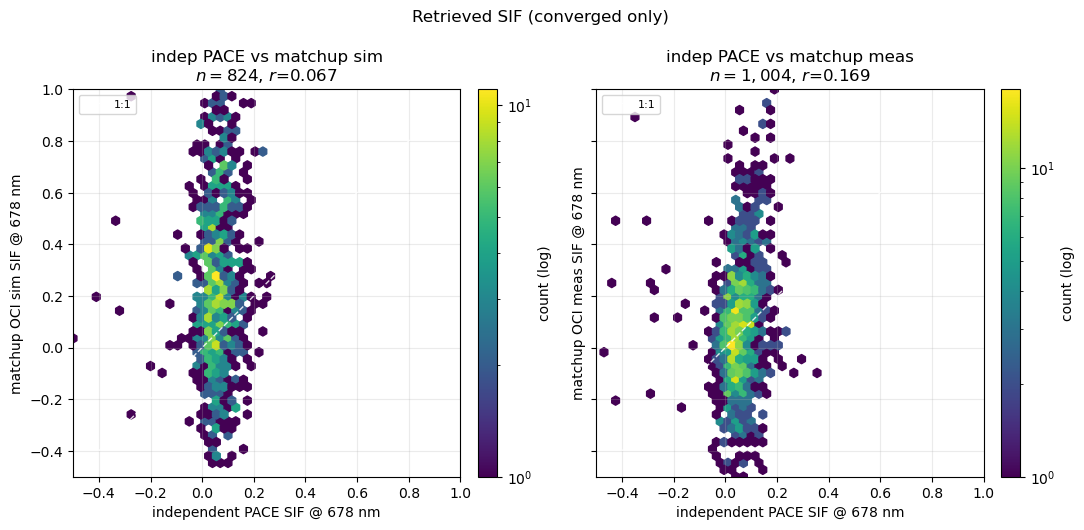

In [108]:
# compare retrieved SIF (converged only): independent PACE vs matchup OCI sim / meas
sif_pace_indep = np.asarray(matchup_sif["sif_pace_678nm"].values, dtype=float)
sif_match_sim = np.asarray(ds_sim["sif_radiance_678nm"].values, dtype=float)
sif_match_meas = np.asarray(ds_meas["sif_radiance_678nm"].values, dtype=float)

conv_pace_indep = np.asarray(matchup_sif["converged_pace"].values).astype(bool)
if "pace_found" in matchup_sif:
    conv_pace_indep &= np.asarray(matchup_sif["pace_found"].values).astype(bool)
conv_match_sim = np.asarray(ds_sim["converged"].values).astype(bool)
conv_match_meas = np.asarray(ds_meas["converged"].values).astype(bool)

m_sim = (
    conv_pace_indep & conv_match_sim
    & np.isfinite(sif_pace_indep) & np.isfinite(sif_match_sim)
)
m_meas = (
    conv_pace_indep & conv_match_meas
    & np.isfinite(sif_pace_indep) & np.isfinite(sif_match_meas)
)
print(f"both converged indep∩sim:  n={m_sim.sum():,}")
print(f"both converged indep∩meas: n={m_meas.sum():,}")

xlim = ylim = (-0.5, 1.0)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, mask, y, ylab, title in [
    (axes[0], m_sim, sif_match_sim, "matchup OCI sim SIF @ 678 nm", "indep PACE vs matchup sim"),
    (axes[1], m_meas, sif_match_meas, "matchup OCI meas SIF @ 678 nm", "indep PACE vs matchup meas"),
]:
    x, yy = sif_pace_indep[mask], y[mask]
    if x.size:
        hb = ax.hexbin(
            x, yy, gridsize=50, mincnt=1, bins="log", cmap="viridis",
            extent=(*xlim, *ylim),
        )
        fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, label="count (log)")
        r = float(np.corrcoef(x, yy)[0, 1]) if x.size > 1 else np.nan
    else:
        r = np.nan
    ax.plot(xlim, ylim, "w--", lw=1.0, alpha=0.85, label="1:1")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("independent PACE SIF @ 678 nm")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title}\n$n={mask.sum():,}$, $r$={r:.3f}")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Retrieved SIF (converged only)", y=1.02)
plt.tight_layout()
plt.show()
